Original data shape: (253, 2)
Date range: 2023-10-02 00:00:00 to 2024-09-30 00:00:00
Filtered data shape: (253, 2)
Matrix shape: (1, 253)
NaNs in data: 0
Train data shape: (1, 211)
Test data shape: (1, 42)

=== Dataset Shapes ===
X_train: (191, 14, 1)
Y_train: (191, 7, 1)
X_test: (22, 14, 1)
Y_test: (22, 7, 1)

=== Sample Data ===
X_train[0] (first 3 timesteps):
 [[2634.75268555]
 [2643.63378906]
 [2651.52832031]]
Y_train[0] (first 3 timesteps):
 [[2607.12207031]
 [2651.52832031]
 [2379.171875  ]]


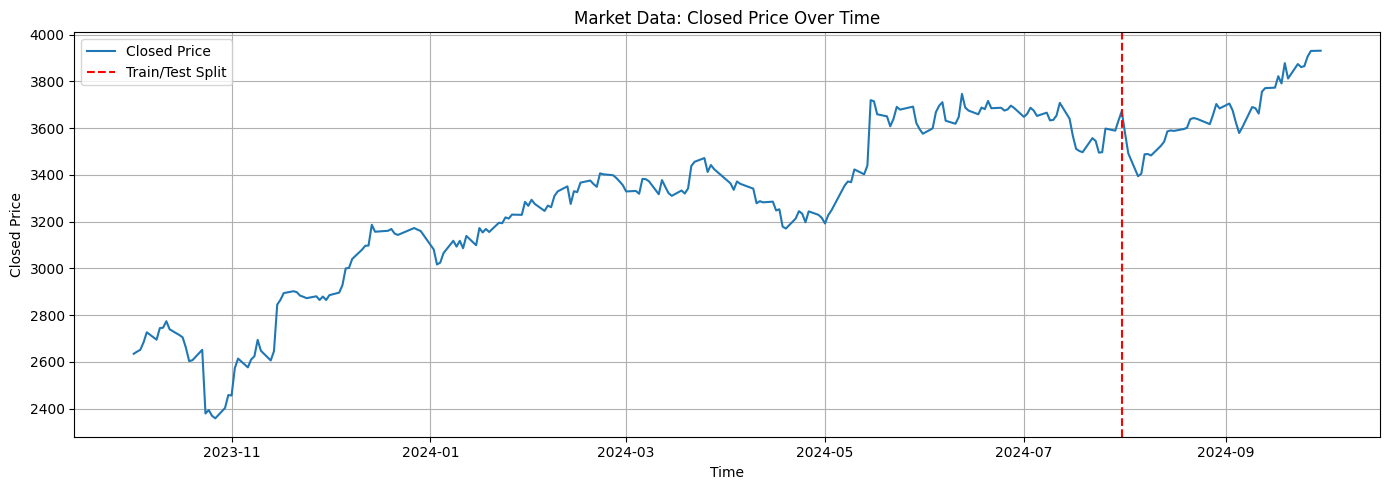


Preprocessed data saved to 'market_preprocessed.npz'


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from datetime import datetime

# Load the JSON file
with open('marketprice.json', 'r') as f:
    data = json.load(f)

# Convert JSON to DataFrame
df = pd.DataFrame(list(data.items()), columns=['time', 'closed_price'])

# Convert time column to datetime
df['time'] = pd.to_datetime(df['time'])

# Sort by time to ensure chronological order
df = df.sort_values('time').reset_index(drop=True)

print("Original data shape:", df.shape)
print("Date range:", df['time'].min(), "to", df['time'].max())

# Define time range for analysis
time_range_start = "2023-10-02"  # Your data starts here
time_range_end = "2024-09-30"    # Your data ends here

# Filter data by time range
df_filtered = df[(df['time'] >= time_range_start) & (df['time'] <= time_range_end)].copy()

# Normalize timestamps to just dates (if needed)
df_filtered['time'] = df_filtered['time'].dt.normalize()

# Remove any duplicate timestamps (keep first occurrence)
df_filtered = df_filtered.drop_duplicates(subset=['time'], keep='first')

print("Filtered data shape:", df_filtered.shape)

# Create matrix format: shape (features, time)
# In this case, we have 1 feature (closed_price) across time
time_series = df_filtered['closed_price'].values  # shape: (time,)
matrix_2d = time_series.reshape(1, -1)  # shape: (1, time) -> (features, time)

print("Matrix shape:", matrix_2d.shape)  # (1, time)

# Check for NaNs
nan_count = np.isnan(matrix_2d).sum()
print(f"NaNs in data: {nan_count}")

# Handle NaNs if present (forward fill then backward fill)
if nan_count > 0:
    df_filtered['closed_price'] = df_filtered['closed_price'].ffill().bfill()
    matrix_2d = df_filtered['closed_price'].values.reshape(1, -1)
    print(f"After handling NaNs: {np.isnan(matrix_2d).sum()}")

# Define train/test split (80/20 split approximately)
train_start = "2023-10-02"
train_end = "2024-07-31"   # ~10 months for training
test_start = "2024-08-01"
test_end = "2024-09-30"    # ~2 months for testing

# Get time index
time_index = df_filtered['time'].values

# Get index positions
train_mask = (df_filtered['time'] >= train_start) & (df_filtered['time'] <= train_end)
test_mask = (df_filtered['time'] >= test_start) & (df_filtered['time'] <= test_end)
train_indices = np.where(train_mask)[0]
test_indices = np.where(test_mask)[0]

# Select train and test data
train_data = matrix_2d[:, train_indices]  # shape: (1, n_train_time)
test_data = matrix_2d[:, test_indices]    # shape: (1, n_test_time)

print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

# Set forecasting parameters
input_window = 14           # number of days used as input
forecast_horizon = 7        # number of future days to predict

def create_multi_step_dataset(data, input_window, forecast_horizon):
    """
    Create dataset for time series forecasting.
    
    Args:
        data: shape (features, time)
        input_window: number of time steps as input
        forecast_horizon: number of future time steps to predict
    
    Returns:
        X: shape (samples, input_window, features)
        Y: shape (samples, forecast_horizon, features)
    """
    X, Y = [], []
    n_features, n_time = data.shape

    for t in range(n_time - input_window - forecast_horizon + 1):
        x = data[:, t:t + input_window]  # shape: (features, input_window)
        y = data[:, t + input_window:t + input_window + forecast_horizon]  # shape: (features, forecast_horizon)
        X.append(x.T)  # shape: (input_window, features)
        Y.append(y.T)  # shape: (forecast_horizon, features)

    return np.array(X), np.array(Y)

# Create training/testing datasets
X_train, Y_train = create_multi_step_dataset(
    train_data,
    input_window,
    forecast_horizon
)

X_test, Y_test = create_multi_step_dataset(
    test_data,
    input_window,
    forecast_horizon
)

print("\n=== Dataset Shapes ===")
print("X_train:", X_train.shape)  # (samples, input_window, features)
print("Y_train:", Y_train.shape)  # (samples, forecast_horizon, features)
print("X_test:", X_test.shape)
print("Y_test:", Y_test.shape)

print("\n=== Sample Data ===")
print("X_train[0] (first 3 timesteps):\n", X_train[0][:3])
print("Y_train[0] (first 3 timesteps):\n", Y_train[0][:3])

# Optional: Visualize the data
plt.figure(figsize=(14, 5))
plt.plot(df_filtered['time'], df_filtered['closed_price'], label='Closed Price')
plt.axvline(x=pd.to_datetime(train_end), color='r', linestyle='--', label='Train/Test Split')
plt.xlabel('Time')
plt.ylabel('Closed Price')
plt.title('Market Data: Closed Price Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Save preprocessed data (optional)
np.savez('market_preprocessed.npz',
         X_train=X_train,
         Y_train=Y_train,
         X_test=X_test,
         Y_test=Y_test,
         train_dates=df_filtered.loc[train_mask, 'time'].values,
         test_dates=df_filtered.loc[test_mask, 'time'].values)

print("\nPreprocessed data saved to 'market_preprocessed.npz'")

In [3]:
import tensorflow as tf

# Flatten output for single feature
Y_train_flat = Y_train.reshape(len(Y_train), -1)  # (samples, 7)
Y_test_flat = Y_test.reshape(len(Y_test), -1)

# Build model
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(14, 1)),  # 14 days, 1 feature
    tf.keras.layers.Dense(7)  # Predict 7 future days
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='mse',
    metrics=['mae']
)

# Train
model.fit(X_train, Y_train_flat, epochs=80, batch_size=32, validation_split=0.2)

# Evaluate
test_loss, test_mae = model.evaluate(X_test, Y_test_flat)
print(f"Test MAE: {test_mae}")

Epoch 1/80


c:\Users\ozixi\Documents\projects\QAI Hack\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 22474994.0000 - mae: 4024.0654 - val_loss: 17161720.0000 - val_mae: 3313.3296
Epoch 2/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 9418710.0000 - mae: 2460.1643 - val_loss: 5643003.5000 - val_mae: 2028.6378
Epoch 3/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 2753342.7500 - mae: 1397.5635 - val_loss: 908794.3750 - val_mae: 830.0066
Epoch 4/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 417436.2188 - mae: 515.1998 - val_loss: 330307.6875 - val_mae: 483.6750
Epoch 5/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 398971.4375 - mae: 521.4460 - val_loss: 1104415.0000 - val_mae: 896.8990
Epoch 6/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 821230.1250 - mae: 772.2910 - val_loss: 1321006.0000 - val_mae: 963.6408
Epoch 7/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 739781.3750 - mae: 718.5588 - val_loss: 826512.4375 - val_mae: 789.2225
Epoch 8/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 367748.3438 - mae: 485.0848 - val_los

Training ensemble of 20 models...

Training model 1/20

Training model 2/20

Training model 3/20

Training model 4/20

Training model 5/20

Training model 6/20

Training model 7/20

Training model 8/20

Training model 9/20

Training model 10/20

Training model 11/20

Training model 12/20

Training model 13/20

Training model 14/20

Training model 15/20

Training model 16/20

Training model 17/20

Training model 18/20

Training model 19/20

Training model 20/20

Ensemble training complete!


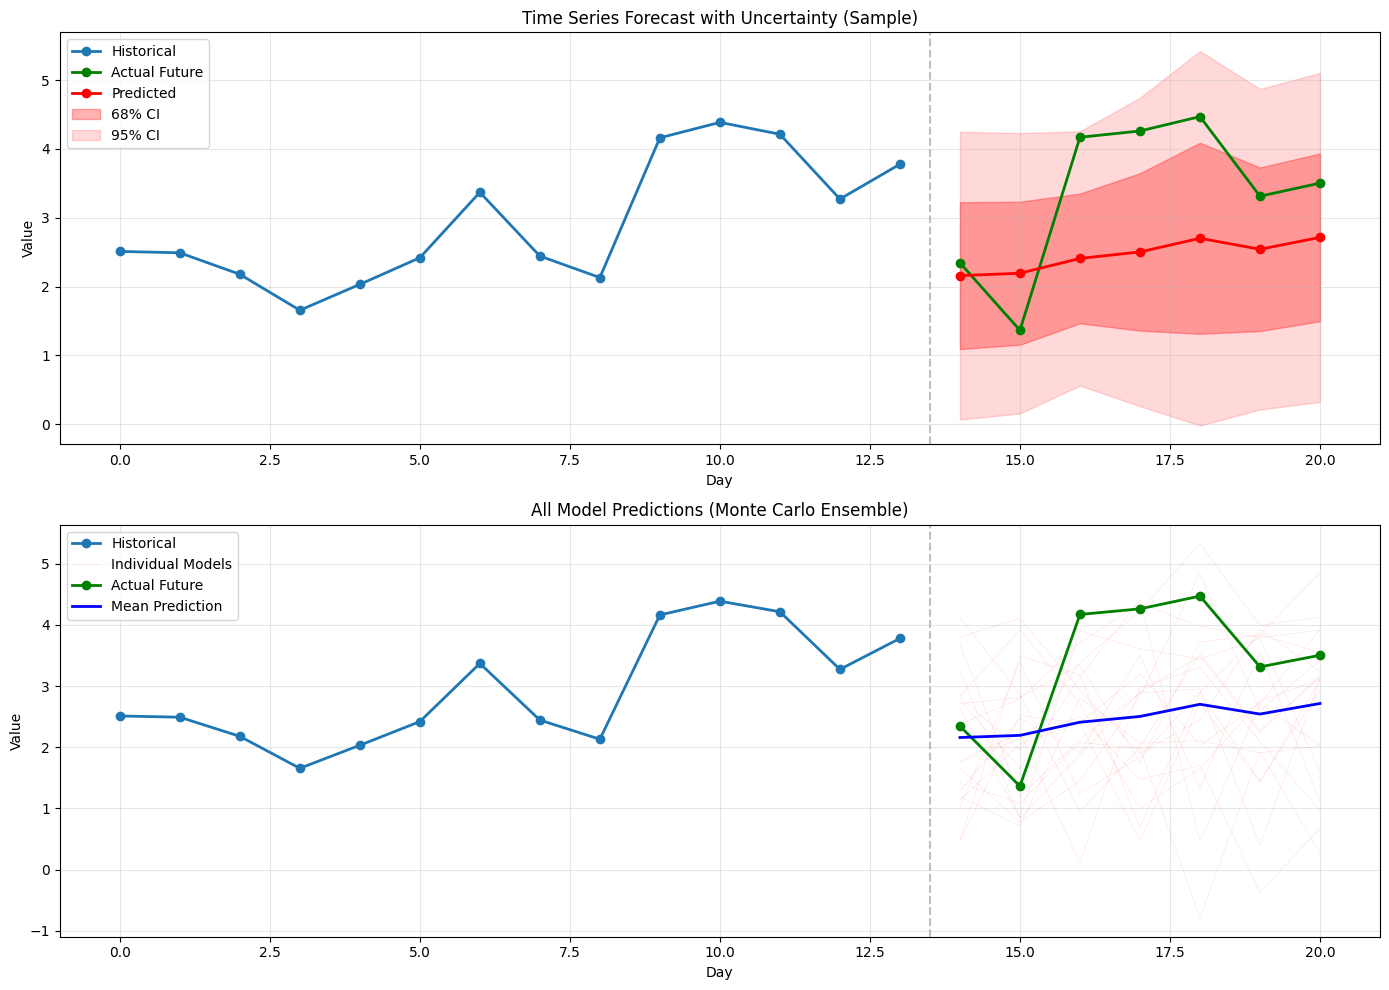


=== Uncertainty Quality Metrics ===
Correlation between error and uncertainty: 0.4882
Mean prediction error: 1.2017
Mean uncertainty (std): 0.8703
Std of prediction errors: 0.9036
68% CI actual coverage: 35.64%
95% CI actual coverage: 69.71%

=== Prediction Statistics ===
Mean prediction: -0.0760
Mean uncertainty: 0.8754
Max uncertainty: 3.0164
Min uncertainty: 0.1166


In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

class MonteCarloTimeSeriesModel:
    """
    Enhanced Monte Carlo simulation for time series forecasting with uncertainty estimation
    """
    
    def __init__(self, input_shape=(14, 1), output_size=7, n_simulations=100):
        self.input_shape = input_shape
        self.output_size = output_size
        self.n_simulations = n_simulations
        self.models = []
        self.history = []
        
    def build_model(self, use_dropout=True, dropout_rate=0.3):
        """Build a single model with optional dropout for MC simulation"""
        model = tf.keras.Sequential([
            tf.keras.layers.Flatten(input_shape=self.input_shape),
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.Dropout(dropout_rate) if use_dropout else tf.keras.layers.Lambda(lambda x: x),
            tf.keras.layers.Dense(64, activation='relu'),
            tf.keras.layers.Dropout(dropout_rate) if use_dropout else tf.keras.layers.Lambda(lambda x: x),
            tf.keras.layers.Dense(32, activation='relu'),
            tf.keras.layers.Dense(self.output_size)
        ])
        
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            loss='mse',
            metrics=['mae']
        )
        
        return model
    
    def train_ensemble(self, X_train, Y_train, epochs=100, batch_size=32, validation_split=0.2):
        """Train multiple models with different initializations"""
        print(f"Training ensemble of {self.n_simulations} models...")
        
        Y_train_flat = Y_train.reshape(len(Y_train), -1)
        
        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True
        )
        
        for i in range(self.n_simulations):
            print(f"\nTraining model {i+1}/{self.n_simulations}")
            
            # Build new model with random initialization
            model = self.build_model(use_dropout=True, dropout_rate=0.3)
            
            # Train model
            history = model.fit(
                X_train, Y_train_flat,
                epochs=epochs,
                batch_size=batch_size,
                validation_split=validation_split,
                callbacks=[early_stop],
                verbose=0
            )
            
            self.models.append(model)
            self.history.append(history)
            
        print("\nEnsemble training complete!")
    
    def predict_with_uncertainty(self, X_test, n_mc_samples=50):
        """
        Generate predictions with uncertainty using Monte Carlo dropout
        
        Returns:
            mean_predictions: Mean predictions across all simulations
            std_predictions: Standard deviation (uncertainty)
            all_predictions: All individual predictions
        """
        all_predictions = []
        
        for model in self.models:
            # Multiple forward passes with dropout enabled
            mc_predictions = []
            for _ in range(n_mc_samples):
                # Predict with dropout enabled (training=True)
                pred = model(X_test, training=True).numpy()
                mc_predictions.append(pred)
            
            # Average predictions from MC samples for this model
            model_mean_pred = np.mean(mc_predictions, axis=0)
            all_predictions.append(model_mean_pred)
        
        all_predictions = np.array(all_predictions)  # Shape: (n_models, n_samples, 7)
        
        # Calculate statistics across all models
        mean_predictions = np.mean(all_predictions, axis=0)
        std_predictions = np.std(all_predictions, axis=0)
        
        return mean_predictions, std_predictions, all_predictions
    
    def calculate_prediction_intervals(self, mean_pred, std_pred, confidence_levels=[0.68, 0.95]):
        """
        Calculate prediction intervals for different confidence levels
        
        confidence_levels: List of confidence levels (e.g., 0.68 = 1 std, 0.95 = 2 std)
        """
        intervals = {}
        
        for conf in confidence_levels:
            # Convert confidence level to number of standard deviations
            if conf == 0.68:
                z = 1.0
            elif conf == 0.95:
                z = 1.96
            elif conf == 0.99:
                z = 2.576
            else:
                z = 1.96  # default
            
            lower = mean_pred - z * std_pred
            upper = mean_pred + z * std_pred
            
            intervals[conf] = {'lower': lower, 'upper': upper}
        
        return intervals
    
    def visualize_predictions(self, X_test, Y_test, sample_idx=0):
        """Visualize predictions with uncertainty bands"""
        mean_pred, std_pred, all_pred = self.predict_with_uncertainty(X_test)
        intervals = self.calculate_prediction_intervals(mean_pred, std_pred)
        
        # Plot for a single sample
        fig, axes = plt.subplots(2, 1, figsize=(14, 10))
        
        # Historical data
        historical = X_test[sample_idx].flatten()
        actual = Y_test[sample_idx].flatten() if len(Y_test.shape) > 1 else Y_test[sample_idx]
        predicted = mean_pred[sample_idx]
        uncertainty = std_pred[sample_idx]
        
        # Plot 1: Full sequence with predictions
        ax1 = axes[0]
        days = np.arange(len(historical) + len(predicted))
        
        # Historical data
        ax1.plot(range(len(historical)), historical, 'o-', label='Historical', linewidth=2)
        
        # Actual future values
        future_days = range(len(historical), len(historical) + len(actual))
        ax1.plot(future_days, actual, 'go-', label='Actual Future', linewidth=2)
        
        # Predicted values
        ax1.plot(future_days, predicted, 'ro-', label='Predicted', linewidth=2)
        
        # Confidence intervals
        ax1.fill_between(future_days, 
                         intervals[0.68]['lower'][sample_idx],
                         intervals[0.68]['upper'][sample_idx],
                         alpha=0.3, color='red', label='68% CI')
        ax1.fill_between(future_days,
                         intervals[0.95]['lower'][sample_idx],
                         intervals[0.95]['upper'][sample_idx],
                         alpha=0.15, color='red', label='95% CI')
        
        ax1.axvline(x=len(historical)-0.5, color='gray', linestyle='--', alpha=0.5)
        ax1.set_xlabel('Day')
        ax1.set_ylabel('Value')
        ax1.set_title('Time Series Forecast with Uncertainty (Sample)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: All model predictions (spaghetti plot)
        ax2 = axes[1]
        ax2.plot(range(len(historical)), historical, 'o-', label='Historical', linewidth=2)
        
        # Plot predictions from all models
        for i, model_pred in enumerate(all_pred[:, sample_idx, :]):
            if i == 0:
                ax2.plot(future_days, model_pred, 'r-', alpha=0.1, linewidth=0.5, label='Individual Models')
            else:
                ax2.plot(future_days, model_pred, 'r-', alpha=0.1, linewidth=0.5)
        
        ax2.plot(future_days, actual, 'go-', label='Actual Future', linewidth=2)
        ax2.plot(future_days, predicted, 'b-', label='Mean Prediction', linewidth=2)
        
        ax2.axvline(x=len(historical)-0.5, color='gray', linestyle='--', alpha=0.5)
        ax2.set_xlabel('Day')
        ax2.set_ylabel('Value')
        ax2.set_title('All Model Predictions (Monte Carlo Ensemble)')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        return mean_pred, std_pred, intervals
    
    def evaluate_uncertainty_quality(self, X_test, Y_test):
        """Evaluate how well uncertainty estimates match actual errors"""
        mean_pred, std_pred, _ = self.predict_with_uncertainty(X_test)
        
        Y_test_flat = Y_test.reshape(len(Y_test), -1)
        
        # Calculate actual errors
        errors = np.abs(Y_test_flat - mean_pred)
        
        # Check calibration: errors should be roughly proportional to std
        correlation = np.corrcoef(errors.flatten(), std_pred.flatten())[0, 1]
        
        print("\n=== Uncertainty Quality Metrics ===")
        print(f"Correlation between error and uncertainty: {correlation:.4f}")
        print(f"Mean prediction error: {np.mean(errors):.4f}")
        print(f"Mean uncertainty (std): {np.mean(std_pred):.4f}")
        print(f"Std of prediction errors: {np.std(errors):.4f}")
        
        # Coverage statistics
        intervals = self.calculate_prediction_intervals(mean_pred, std_pred)
        
        for conf, interval in intervals.items():
            within_interval = np.logical_and(
                Y_test_flat >= interval['lower'],
                Y_test_flat <= interval['upper']
            )
            coverage = np.mean(within_interval)
            print(f"{int(conf*100)}% CI actual coverage: {coverage*100:.2f}%")


# Example usage
if __name__ == "__main__":
    # Generate synthetic data for demonstration
    np.random.seed(42)
    
    # Create synthetic time series data
    n_samples = 1000
    X_train = np.random.randn(n_samples, 14, 1).cumsum(axis=1)
    Y_train = X_train[:, -7:, 0] + np.random.randn(n_samples, 7) * 0.5
    
    X_test = np.random.randn(200, 14, 1).cumsum(axis=1)
    Y_test = X_test[:, -7:, 0] + np.random.randn(200, 7) * 0.5
    
    # Initialize and train Monte Carlo model
    mc_model = MonteCarloTimeSeriesModel(
        input_shape=(14, 1),
        output_size=7,
        n_simulations=20  # Number of models in ensemble
    )
    
    # Train ensemble
    mc_model.train_ensemble(X_train, Y_train, epochs=50, batch_size=32)
    
    # Get predictions with uncertainty
    mean_pred, std_pred, all_pred = mc_model.predict_with_uncertainty(X_test, n_mc_samples=30)
    
    # Visualize results
    mc_model.visualize_predictions(X_test, Y_test, sample_idx=0)
    
    # Evaluate uncertainty quality
    mc_model.evaluate_uncertainty_quality(X_test, Y_test)
    
    print("\n=== Prediction Statistics ===")
    print(f"Mean prediction: {np.mean(mean_pred):.4f}")
    print(f"Mean uncertainty: {np.mean(std_pred):.4f}")
    print(f"Max uncertainty: {np.max(std_pred):.4f}")
    print(f"Min uncertainty: {np.min(std_pred):.4f}")

Training ensemble of 20 models...

Training model 1/20

Training model 2/20

Training model 3/20

Training model 4/20

Training model 5/20

Training model 6/20

Training model 7/20

Training model 8/20

Training model 9/20

Training model 10/20

Training model 11/20

Training model 12/20

Training model 13/20

Training model 14/20

Training model 15/20

Training model 16/20

Training model 17/20

Training model 18/20

Training model 19/20

Training model 20/20

Ensemble training complete!


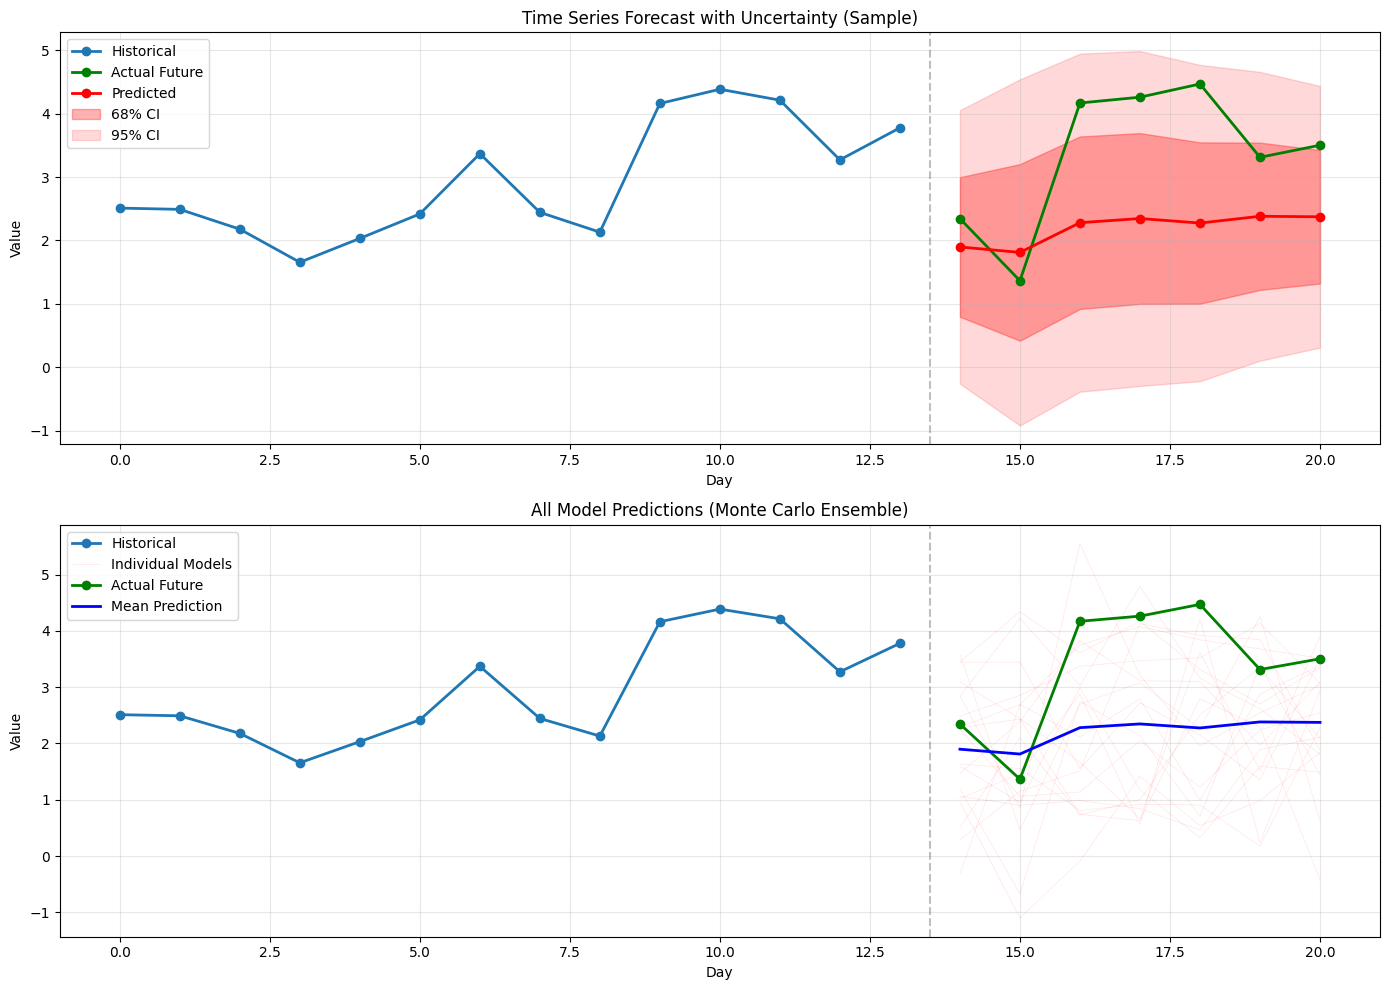


=== Uncertainty Quality Metrics ===
Correlation between error and uncertainty: 0.5206
Mean prediction error: 1.2107
Mean uncertainty (std): 0.9135
Std of prediction errors: 0.9302
68% CI actual coverage: 38.93%
95% CI actual coverage: 72.64%


In [5]:
# Initialize model
mc_model = MonteCarloTimeSeriesModel(
    input_shape=(14, 1),
    output_size=7,
    n_simulations=20  # Adjust based on compute resources
)

# Train ensemble
mc_model.train_ensemble(X_train, Y_train, epochs=100)

# Get predictions with uncertainty
mean_pred, std_pred, all_pred = mc_model.predict_with_uncertainty(X_test)

# Visualize
mc_model.visualize_predictions(X_test, Y_test, sample_idx=0)

# Evaluate uncertainty quality
mc_model.evaluate_uncertainty_quality(X_test, Y_test)